# M1M9 True-component Hybrid EnbPI benchmark

這是 KF decomposition 的 paired ablation。Current 組使用 causal KF estimated low/high；True-component 組跳過 KF，改用模擬的 true low/high 歷史，但兩組使用完全相同的 ARIMA、ANN、moving-block bootstrap、nested OOB、bias correction 與 EnbPI。預測時間 $t$ 只能使用到 $t-1$ 的 true components，不會使用未來值。比較表另外列出 Equation Oracle RMSE，形成 Current KF Hybrid、True-component Hybrid、Equation Oracle 三層比較。

In [1]:
import importlib
import pandas as pd
from kf_forecasting.models import kf_enbpi, kf_true_component_benchmark
importlib.reload(kf_enbpi)
importlib.reload(kf_true_component_benchmark)

from kf_forecasting.models.kf_enbpi import EnbPIConfig
from kf_forecasting.models.kf_true_component_benchmark import (
    run_paired_true_component_experiment, paired_comparison_table,
    paired_true_component_monte_carlo, plot_paired_comparison,
    plot_representative_pair,
)
pd.set_option('display.precision', 4)
print('Loaded:', kf_enbpi.__file__)
print('Loaded:', kf_true_component_benchmark.__file__)

Loaded: C:\Users\User\Desktop\程式\project\meeting\src\kf_forecasting\models\kf_enbpi.py
Loaded: C:\Users\User\Desktop\程式\project\meeting\src\kf_forecasting\models\kf_true_component_benchmark.py


## Paired configuration
兩組共用相同 data seed 與 ensemble seed。因每個 Monte Carlo run 會各跑 Current 與 True-component 兩套完整 EnbPI，時間約為原本的兩倍。

In [2]:
config = EnbPIConfig(
    window_size=15, alpha=0.05, n_bootstrap=30, block_length=None,
    batch_size=1, beta_grid_size=101,
    oob_bias_correction=True, oob_bias_correction_mode='combined',
    arima_order=None, arima_max_p=4, arima_max_q=4,
    ann_hidden_layers=(32, 16), ann_max_iter=500, ann_alpha=1e-4,
    ann_learning_rate_init=1e-3, ann_target_standardization=True,
    ann_early_stopping=False, ann_rolling_validation=True,
    ann_rolling_splits=3, ann_validation_fraction=0.10,
    ann_iteration_candidates=(125, 250, 500), ann_tol=1e-3,
    random_state=1234,
)
train_size = 650
horizon = 50
n_runs = 20

## Single paired run

,model,data_seed,kf_final_rmse,true_component_final_rmse,equation_oracle_rmse,rmse_gain_kf_minus_true_component,kf_to_true_component_rmse_ratio,kf_minus_equation_oracle_rmse,true_component_minus_equation_oracle_rmse,kf_final_coverage,true_component_final_coverage,kf_final_mean_width,true_component_final_mean_width,kf_low_true_rmse,true_component_low_rmse,kf_high_true_rmse,true_component_high_rmse
0,M1M9,2026,2.0952,2.0773,1.9498,0.0179,1.0086,0.1454,0.1275,0.94,0.94,7.7781,7.9079,2.0424,1.0008,2.6809,1.6861


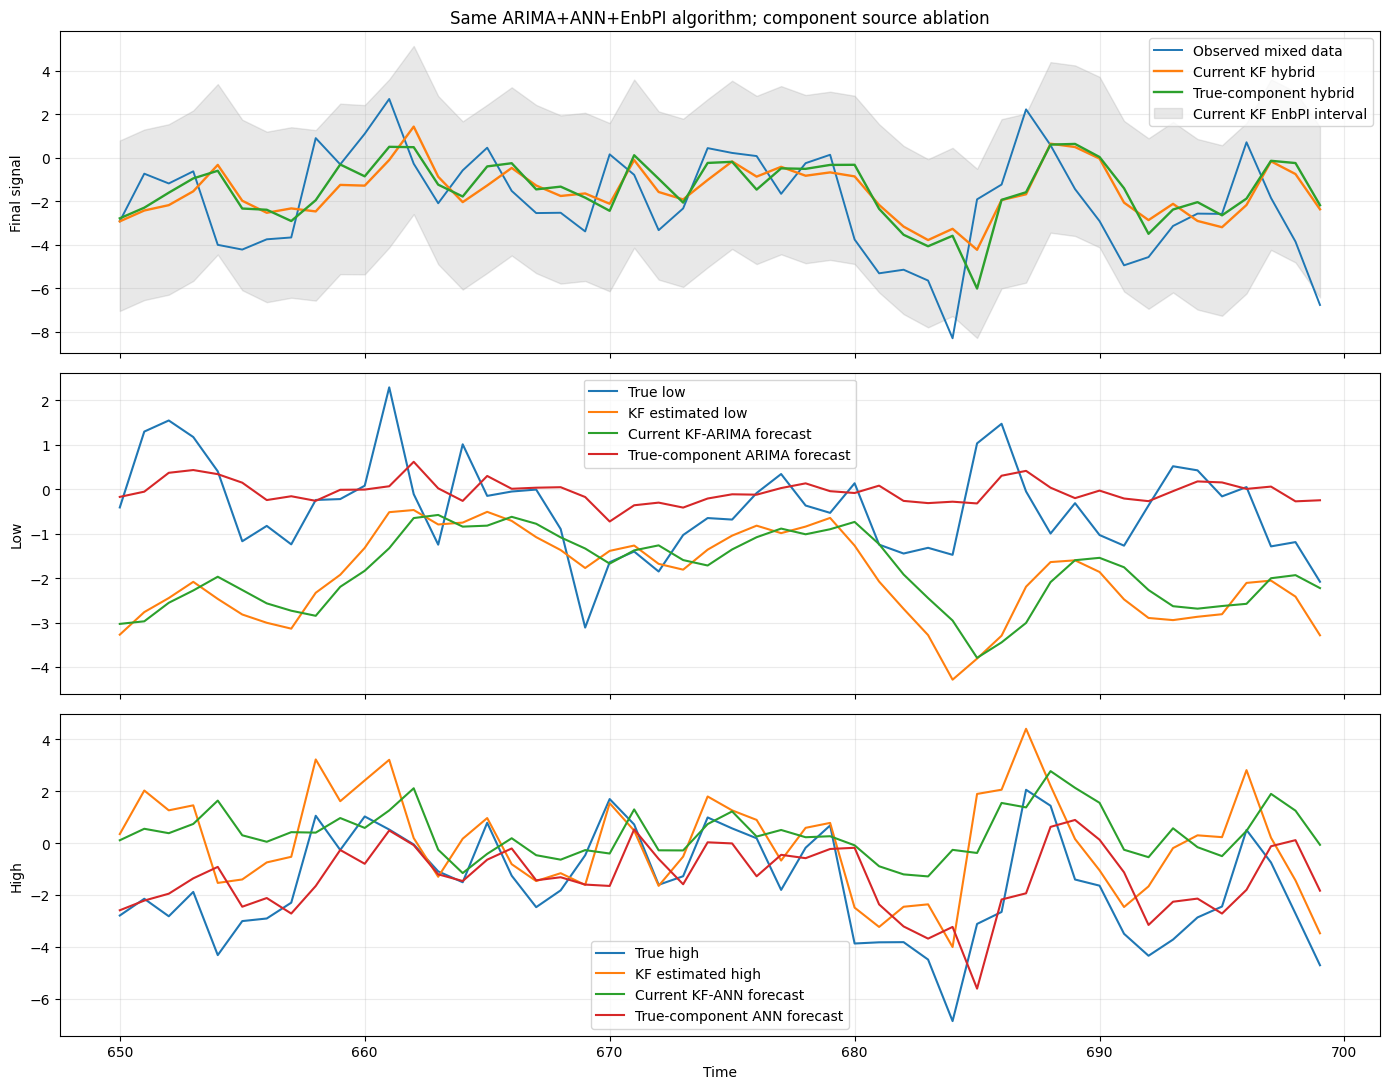

In [3]:
current_result, true_component_result = run_paired_true_component_experiment(
    'm1m9', train_size=train_size, horizon=horizon,
    config=config, data_seed=2026,
)
display(paired_comparison_table(current_result, true_component_result))
plot_paired_comparison(current_result, true_component_result);

## Paired Monte Carlo
`rmse_gain_kf_minus_true_component > 0` 表示移除 KF decomposition 後改善；接近 0 表示 KF component 雖不等於 true component，但沒有明顯傷害最終預測。`true_component_minus_equation_oracle_rmse` 則衡量相同 ARIMA+ANN 流程距離已知方程式條件平均的差距。

,metric,mean,std
0,kf_final_rmse,1.8744,0.2658
1,true_component_final_rmse,1.9451,0.2764
2,equation_oracle_rmse,1.7630,0.2452
3,rmse_gain_kf_minus_true_component,-0.0707,0.0936
4,kf_to_true_component_rmse_ratio,0.9651,0.0454
5,kf_minus_equation_oracle_rmse,0.1114,0.1087
6,true_component_minus_equation_oracle_rmse,0.1821,0.1497
7,kf_final_coverage,0.9520,0.0321
8,true_component_final_coverage,0.9510,0.0294
9,kf_final_mean_width,7.5677,0.3199


,run,data_seed,kf_final_rmse,true_component_final_rmse,equation_oracle_rmse,rmse_gain_kf_minus_true_component,kf_to_true_component_rmse_ratio,kf_minus_equation_oracle_rmse,true_component_minus_equation_oracle_rmse,kf_final_coverage,true_component_final_coverage,kf_final_mean_width,true_component_final_mean_width,kf_low_true_rmse,true_component_low_rmse,kf_high_true_rmse,true_component_high_rmse
0,1,479243620,1.6077,1.6026,1.6810,0.0051,1.0032,-0.0733,-0.0784,0.96,0.96,6.8369,7.2518,1.3103,0.8203,1.6456,1.3952
1,2,454024514,1.7187,1.6756,1.6233,0.0431,1.0257,0.0954,0.0523,0.98,0.98,7.4476,7.8812,1.3781,1.0210,1.3481,1.3767
2,3,1818751028,1.7226,1.8330,1.6210,-0.1104,0.9398,0.1016,0.2120,0.98,0.96,7.4030,8.0729,1.7083,0.9828,2.0165,1.6811
3,4,2288458700,2.3291,2.3366,2.1771,-0.0075,0.9968,0.1520,0.1595,0.88,0.90,7.6617,7.8015,3.2616,1.1403,4.1850,1.9713
4,5,2115331525,1.7011,1.7362,1.5283,-0.0351,0.9798,0.1728,0.2079,0.98,0.98,7.7192,7.7470,1.2152,1.2005,1.1605,1.2304
5,6,2666256175,2.0861,2.0889,1.7194,-0.0028,0.9986,0.3666,0.3695,0.92,0.94,7.3543,7.4357,2.1712,1.3720,3.0991,1.6393
6,7,975381835,1.5960,1.6936,1.5416,-0.0976,0.9424,0.0544,0.1520,0.98,0.96,7.5445,7.5491,1.7746,0.9948,1.9413,1.4763
7,8,2535166222,2.1953,2.3289,1.9209,-0.1336,0.9426,0.2744,0.4079,0.90,0.90,7.8260,7.9661,1.6686,1.2655,1.9791,1.8677
8,9,1079577930,1.6301,1.7002,1.4851,-0.0701,0.9588,0.1450,0.2151,0.98,0.98,7.9621,7.8860,1.6095,1.1654,1.5711,1.3655
9,10,3715024065,2.0704,2.2454,1.8320,-0.1750,0.9221,0.2384,0.4134,0.92,0.92,7.5847,7.8939,1.7538,1.2553,2.6097,1.8399


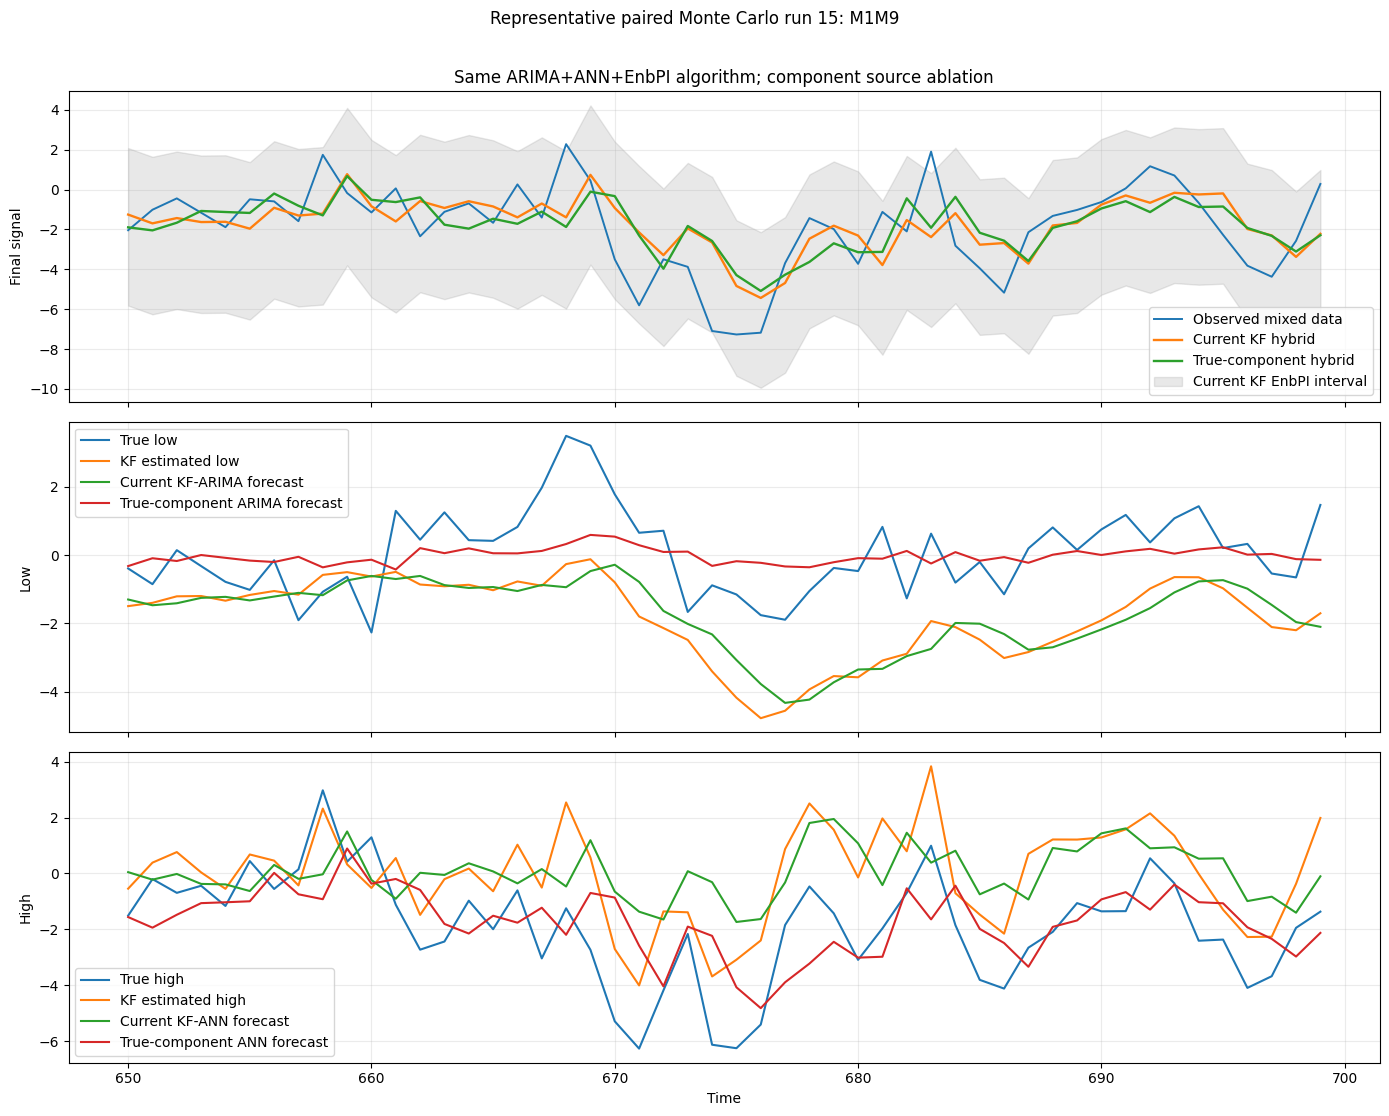

In [4]:
paired_runs, paired_summary, current_results, true_component_results = (
    paired_true_component_monte_carlo(
        'm1m9', n_runs=n_runs, train_size=train_size, horizon=horizon,
        config=config, seed=2026,
    )
)
display(paired_summary)
display(paired_runs)
plot_representative_pair(
    paired_runs, current_results, true_component_results, model_name='m1m9'
);